<a href="https://colab.research.google.com/github/jiafenggang/Algo_F/blob/master/synthmorph_ct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This demo showcases brain-specific registration of computed tomography (CT) to
# magnetic resonance images (MRI) with SynthMorph. Further information is
# available at: https://synthmorph.io.
#
# If you find the demo useful, please cite:
#
#     Anatomy-aware and acquisition-agnostic joint registration with SynthMorph
#     Hoffmann M, Hoopes A, Greve DN, Fischl B*, Dalca AV* (*equal contribution)
#     Imaging Neuroscience, 2, pp 1-33, 2024
#     https://doi.org/10.1162/imag_a_00197
#
# We distribute this notebook under the MIT License:
# https://choosealicense.com/licenses/mit

In [ ]:
# Packages from GitHub.
!pip -q install https://github.com/adalca/neurite/archive/17aa080540b61e72ed1f5f37378df41c8278dc3e.zip
!pip -q install https://github.com/freesurfer/surfa/archive/8de6c4584eee9283c50f2d7e215eaf8ff1469770.zip
!pip -q install https://github.com/voxelmorph/voxelmorph/archive/cc84aa7fe255bac6f3bad6f124106e61ea9312cf.zip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.8/133.8 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     \ 131.4 kB 1.2 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     | 63.9 MB 36.6 MB/s 0:00:04
  Preparing metadata (setup.py) ... done


In [ ]:
import surfa as sf
import matplotlib.pyplot as plt

In [ ]:
# Downloads. CT from subject 77654033 in Patient-Contributed Image Repository
# (https://www.pcir.org/researchers/77654033_19950903.html), T1-weighted MRI
# from subject Afterthought in Mindboggle-101 (https://mindboggle.info).
%%sh
mkdir -p models synthmorph
get() { ( cd "${2:-.}" ; curl -C- -O "$1" ; ) }

url=https://raw.githubusercontent.com/freesurfer/freesurfer/9f23ef349976e3b455778f865bceed24d79aa89d
get $url/mri_synthmorph/mri_synthmorph
get $url/mri_synthmorph/synthmorph/registration.py synthmorph
get $url/mri_synthmorph/synthmorph/utils.py synthmorph

get https://surfer.nmr.mgh.harvard.edu/docs/synthmorph/images/ct.nii.gz
get https://surfer.nmr.mgh.harvard.edu/docs/synthmorph/images/t1.nii.gz
get https://surfer.nmr.mgh.harvard.edu/docs/synthmorph/synthmorph.affine.2.h5 models

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 15350  100 15350    0     0  64257      0 --:--:-- --:--:-- --:--:-- 64225
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 11569  100 11569    0     0  48111      0 --:--:-- --:--:-- --:--:-- 48204
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  2890  100  2890    0     0  12495      0 --:--:-- --:--:-- --:--:-- 12510
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 47.3M  100 47.3M    0     0  1374k      0  0:00:35  0:00:35 --:--:-- 1409k
  % Total    % Received % Xferd  Average Speed   Tim

In [ ]:
# SynthMorph setup.
%env FREESURFER_HOME=/content
!chmod +x mri_synthmorph
!./mri_synthmorph

env: FREESURFER_HOME=/content
usage: mri_synthmorph [-h] {register,apply} ...


In [ ]:
# Helper functions.
def normalize(x):
  x -= x.min()
  return x / x.max()


def show(im, title=None):
  im = im.resize(voxsize=1).reshape((256, 256, 256)).reorient('ILP').data
  fig, axes = plt.subplots(1, 3, figsize=(12, 4))

  slices = im[:, 125, :], im[:, :, 127], im[127, :, :].T
  for im, ax in zip(slices, axes):
    ax.imshow(im, cmap='gray')
    ax.set_axis_off()

  if title:
    axes[1].text(0.50, 1.05, title, ha='center', transform=axes[1].transAxes, size=14)

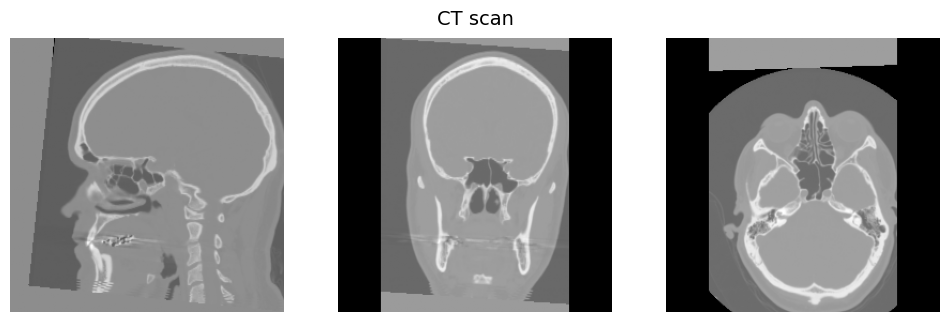

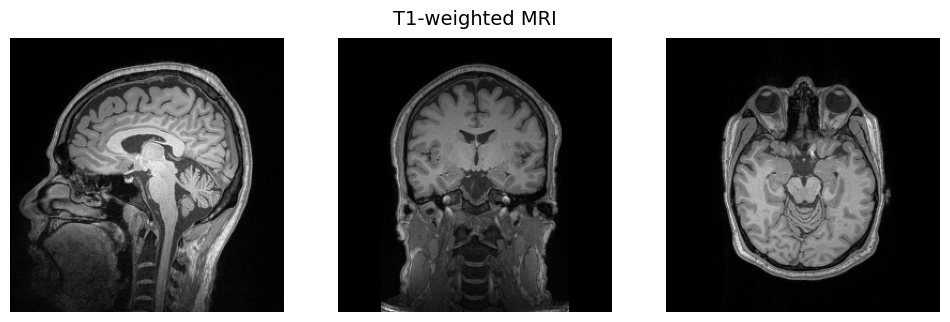

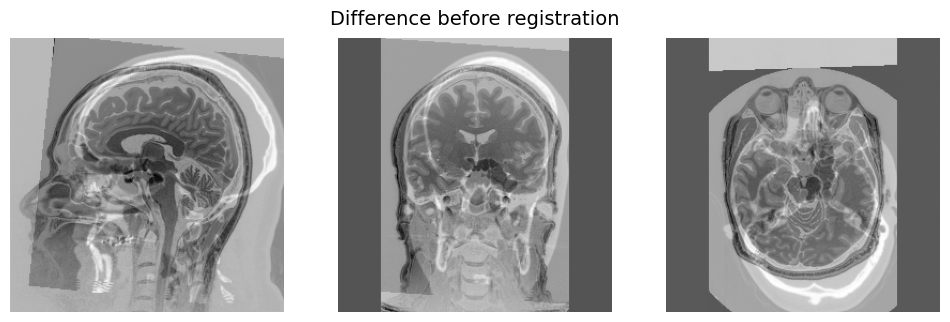

In [ ]:
# Difference before registration.
t1 = sf.load_volume('t1.nii.gz')
ct = sf.load_volume('ct.nii.gz').resample_like(t1)
before = normalize(ct) - normalize(t1)

show(ct, title='CT scan')
show(t1, title='T1-weighted MRI')
show(before, title='Difference before registration')

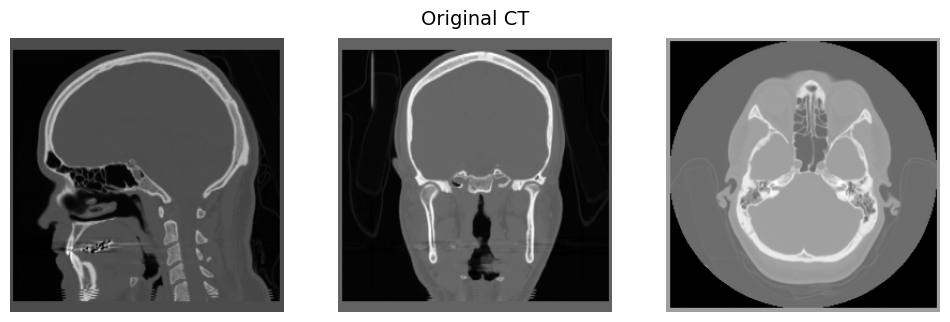

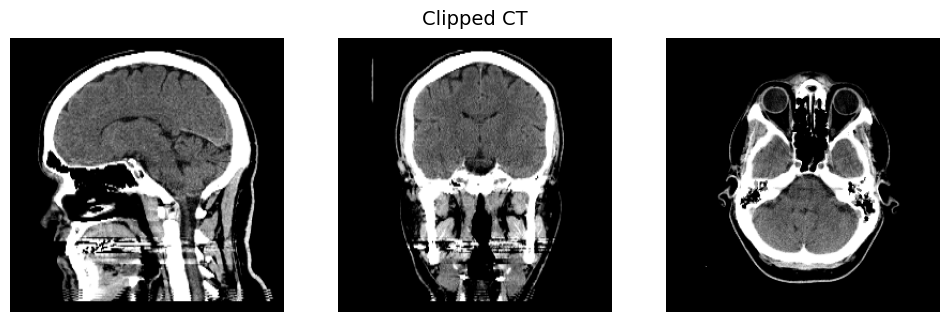

In [ ]:
# CT clipping. Limit intensity scale to 0-80 in Hounsfield units (HU) to bring
# out soft-tissue contrast across the brain. SynthMorph also requires most of
# the brain to be within a 256-mm cube centered on the origin of physical space.
ct = sf.load_volume('ct.nii.gz')
clipped = ct.clip(0, 80)
clipped.save('clipped.nii.gz')

show(ct, title='Original CT')
show(clipped, title='Clipped CT')

In [ ]:
# Brain-specific registration.
!./mri_synthmorph -m affine -t trans.lta clipped.nii.gz t1.nii.gz

E0000 00:00:1755871084.794279     964 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755871084.802098     964 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755871084.821004     964 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755871084.821046     964 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755871084.821052     964 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755871084.821056     964 computation_placer.cc:177] computation placer already registered. Please check linka

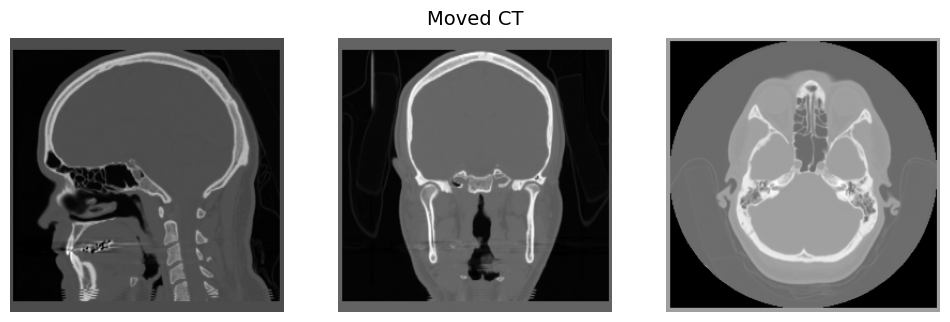

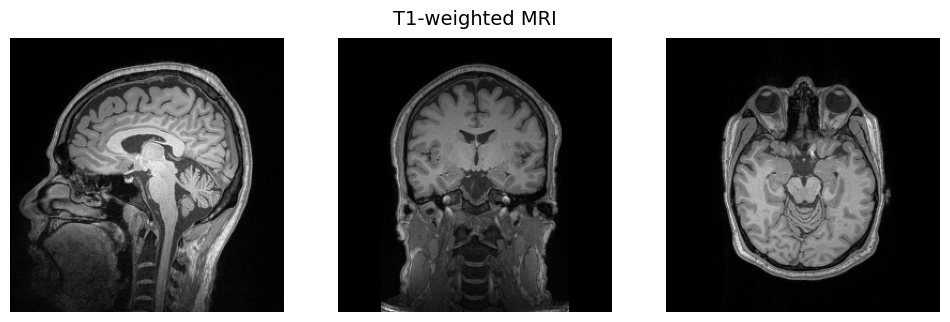

In [ ]:
# Moved CT scan.
trans = sf.load_affine('trans.lta')
moved = sf.load_volume('ct.nii.gz').transform(trans)

show(ct, title='Moved CT')
show(t1, title='T1-weighted MRI')

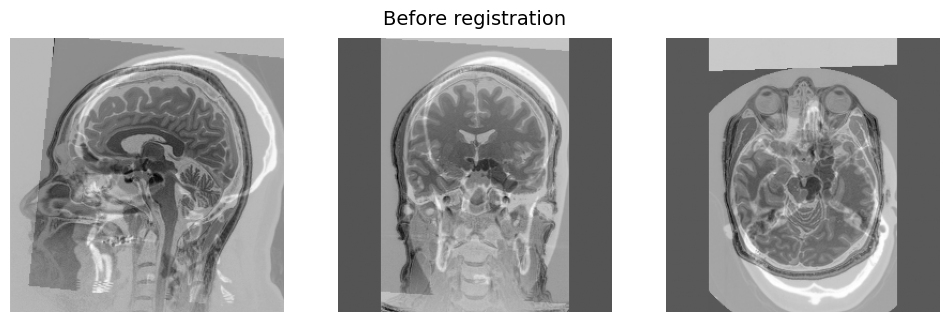

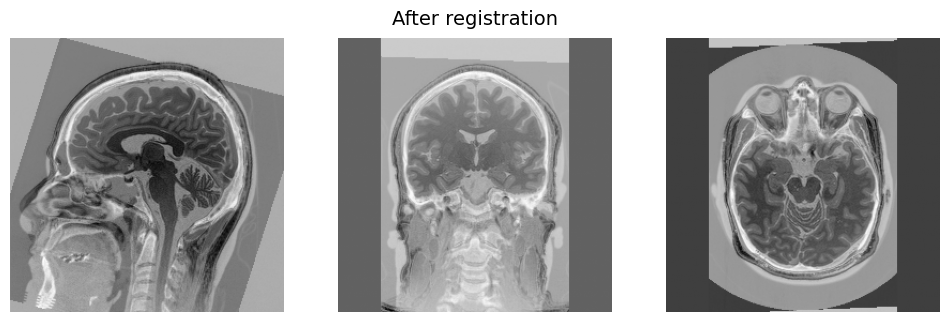

In [ ]:
# Difference after registration.
after = normalize(moved) - normalize(t1)
show(before, title='Before registration')
show(after, title='After registration')

In [ ]:
# Package versions.
!pip freeze

absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.10.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.12.15
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
altair==5.5.0
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.10.0
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.7.2
arviz==0.22.0
astropy==7.1.0
astropy-iers-data==0.2025.8.18.0.40.14
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
Authlib==1.6.1
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.21.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.15.0
bigquery-magics==0.10.2
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.0.0
blosc2==3.7.1
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.1
Brotli==1.1.0
build==1.3.0
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.8.3
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.3
chex==0.1.90
clarabel==0.11.1
click==8.2.1
cl